# 👥 Notebook 03 — Análise de Clientes, Recompra e Churn (Olist)

**Objetivo:** Analisar a base de clientes da Olist, identificar a taxa de recompra (recorrência), realizar análise de Cohort de retenção mensal e quantificar a taxa de churn e Pareto de receita.

## 1. Importações e Configurações

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Detecção dinâmica de caminhos para dados e outputs
DATA_DIR = '../data/olist' if os.path.exists('../data/olist') else 'data/olist'
if not os.path.exists(DATA_DIR):
    DATA_DIR = '/home/jorge/Documents/tech-challenge-agentes-ia/data/olist'

OUTPUT_DIR = './outputs' if os.path.exists('./outputs') or os.path.basename(os.getcwd()) == 'notebooks' else 'notebooks/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"📁 Diretório de Dados: {os.path.abspath(DATA_DIR)}")
print(f"📁 Diretório de Outputs: {os.path.abspath(OUTPUT_DIR)}")


📁 Diretório de Dados: /home/jorge/Documents/tech-challenge-agentes-ia/data/olist
📁 Diretório de Outputs: /home/jorge/Documents/tech-challenge-agentes-ia/notebooks/outputs


## 2. Carregamento dos Dados

In [2]:
customers = pd.read_csv(os.path.join(DATA_DIR, 'olist_customers_dataset.csv'))
orders = pd.read_csv(os.path.join(DATA_DIR, 'olist_orders_dataset.csv'))
items = pd.read_csv(os.path.join(DATA_DIR, 'olist_order_items_dataset.csv'))
payments = pd.read_csv(os.path.join(DATA_DIR, 'olist_order_payments_dataset.csv'))
reviews = pd.read_csv(os.path.join(DATA_DIR, 'olist_order_reviews_dataset.csv'))

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
cust_orders = orders.merge(customers, on='customer_id', how='left')
print(f"✓ Total de registros de pedidos de clientes: {cust_orders.shape[0]}")


✓ Total de registros de pedidos de clientes: 99441


## 3. Distribuição Geográfica e Crescimento da Base

/run/user/1000/snap.antigravity/ipykernel_43812/1069086079.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_counts.index, y=state_counts.values, palette='viridis')


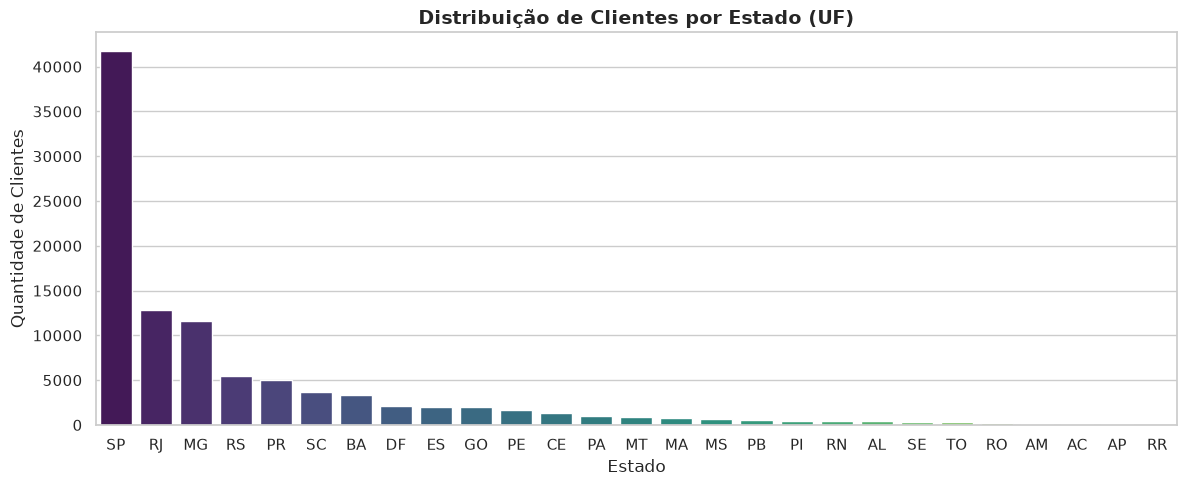

In [3]:
state_counts = customers['customer_state'].value_counts()

plt.figure(figsize=(12, 5))
sns.barplot(x=state_counts.index, y=state_counts.values, palette='viridis')
plt.title('Distribuição de Clientes por Estado (UF)', fontsize=14, fontweight='bold')
plt.xlabel('Estado')
plt.ylabel('Quantidade de Clientes')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '03_clientes_por_estado.png'))
plt.show()


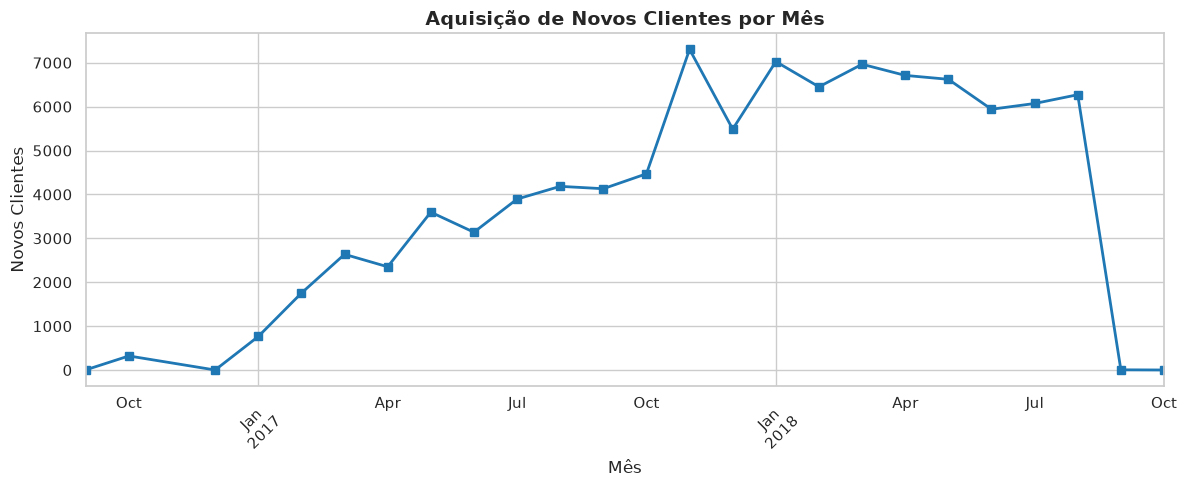

In [4]:
cust_first_order = cust_orders.groupby('customer_unique_id')['order_purchase_timestamp'].min().reset_index()
cust_first_order['cohort_month'] = cust_first_order['order_purchase_timestamp'].dt.to_period('M')
new_cust_by_month = cust_first_order.groupby('cohort_month').size()

plt.figure(figsize=(12, 5))
new_cust_by_month.plot(kind='line', marker='s', color='#1f77b4', linewidth=2)
plt.title('Aquisição de Novos Clientes por Mês', fontsize=14, fontweight='bold')
plt.xlabel('Mês')
plt.ylabel('Novos Clientes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '03_novos_clientes_mes.png'))
plt.show()


## 4. Comportamento de Compra e Taxa de Recompra

In [5]:
orders_per_customer = cust_orders.groupby('customer_unique_id')['order_id'].nunique()
single_order_cust = (orders_per_customer == 1).sum()
multi_order_cust = (orders_per_customer > 1).sum()
total_unique = len(orders_per_customer)
recompra_rate = (multi_order_cust / total_unique) * 100

print(f"👤 Total de Clientes Únicos: {total_unique:,}")
print(f"1️⃣ Clientes com Apenas 1 Pedido: {single_order_cust:,} ({(single_order_cust/total_unique)*100:.2f}%)")
print(f"🔄 Clientes com 2+ Pedidos (Recorrentes): {multi_order_cust:,} ({recompra_rate:.2f}%)")
print(f"⚠️ TAXA DE RECOMPRA DA OLIST: {recompra_rate:.2f}%")


👤 Total de Clientes Únicos: 96,096
1️⃣ Clientes com Apenas 1 Pedido: 93,099 (96.88%)
🔄 Clientes com 2+ Pedidos (Recorrentes): 2,997 (3.12%)
⚠️ TAXA DE RECOMPRA DA OLIST: 3.12%


/run/user/1000/snap.antigravity/ipykernel_43812/4075472489.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=np.clip(orders_per_customer, 1, 5), palette='mako')


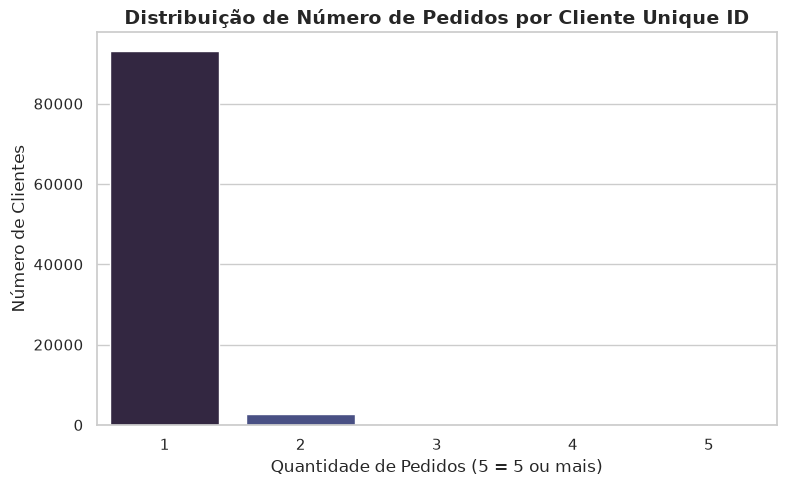

In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(x=np.clip(orders_per_customer, 1, 5), palette='mako')
plt.title('Distribuição de Número de Pedidos por Cliente Unique ID', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade de Pedidos (5 = 5 ou mais)')
plt.ylabel('Número de Clientes')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '03_pedidos_por_cliente.png'))
plt.show()


## 5. Análise de Cohort (Retenção Mensal)

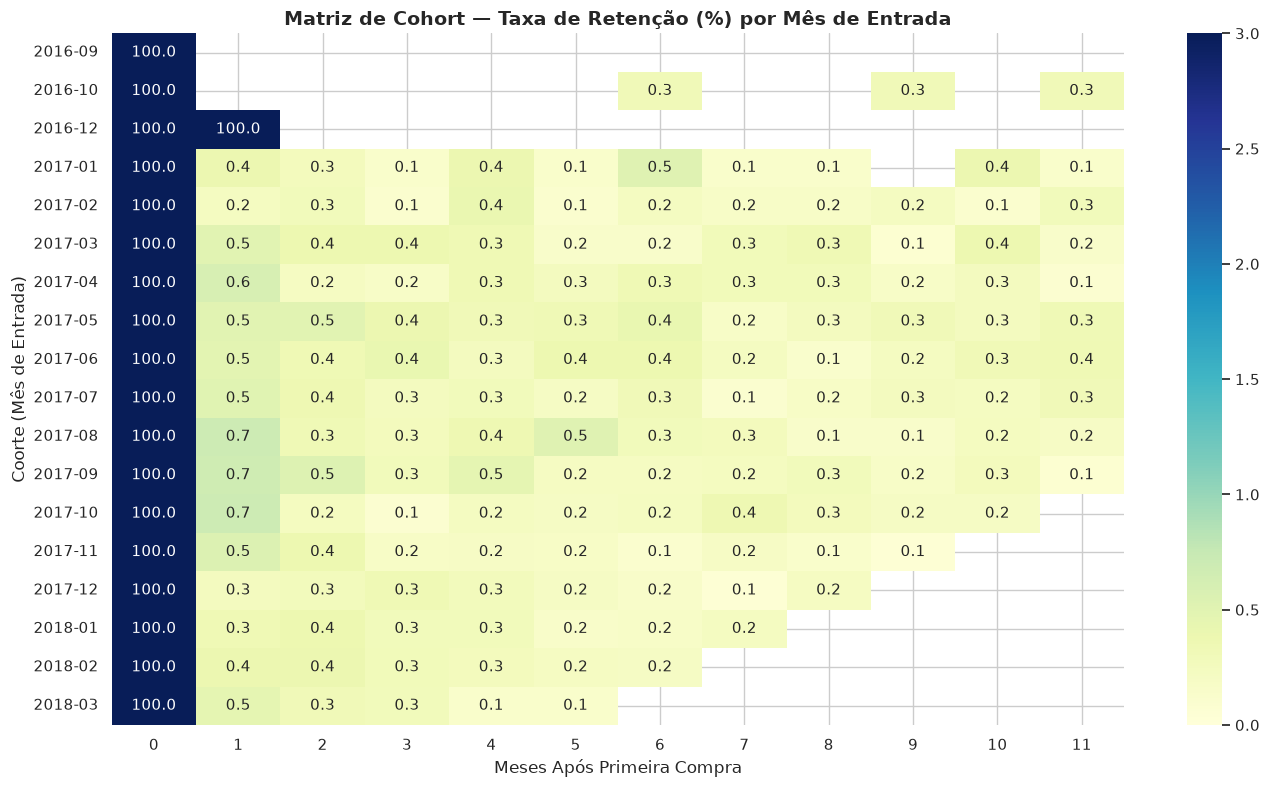

In [7]:
def get_month_int(df, column):
    year = df[column].dt.year
    month = df[column].dt.month
    return year, month

cust_orders['order_month'] = cust_orders['order_purchase_timestamp'].dt.to_period('M')
cust_orders['cohort_month'] = cust_orders.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('M')

cohort_group = cust_orders.groupby(['cohort_month', 'order_month'])
cohort_data = cohort_group.agg({'customer_unique_id': 'nunique'}).reset_index()

cohort_data['period_number'] = (cohort_data['order_month'] - cohort_data['cohort_month']).apply(lambda x: x.n)
cohort_pivot = cohort_data.pivot(index='cohort_month', columns='period_number', values='customer_unique_id')
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0) * 100

plt.figure(figsize=(14, 8))
sns.heatmap(retention.iloc[:18, :12], annot=True, fmt='.1f', cmap='YlGnBu', vmin=0, vmax=3)
plt.title('Matriz de Cohort — Taxa de Retenção (%) por Mês de Entrada', fontsize=14, fontweight='bold')
plt.xlabel('Meses Após Primeira Compra')
plt.ylabel('Coorte (Mês de Entrada)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '03_cohort_retention.png'))
plt.show()


## 6. Análise de Churn e Valor do Cliente (Pareto)

In [8]:
max_date = cust_orders['order_purchase_timestamp'].max()
cust_summary = cust_orders.groupby('customer_unique_id').agg(
    last_order=('order_purchase_timestamp', 'max'),
    order_count=('order_id', 'nunique')
).reset_index()

cust_summary['days_since_last'] = (max_date - cust_summary['last_order']).dt.days
churn_threshold = 180 # 6 meses
churned_cust = (cust_summary['days_since_last'] > churn_threshold).sum()
churn_rate = (churned_cust / len(cust_summary)) * 100

print(f"🔴 Clientes Inativos (> {churn_threshold} dias): {churned_cust:,}")
print(f"🔴 TAXA DE CHURN DA BASE: {churn_rate:.2f}%")

# Pareto de Clientes
cust_spend = cust_orders.merge(payments, on='order_id').groupby('customer_unique_id')['payment_value'].sum().sort_values(ascending=False)
top_10_pct_count = int(len(cust_spend) * 0.10)
top_10_pct_revenue = cust_spend.head(top_10_pct_count).sum()
total_spent_all = cust_spend.sum()
pareto_pct = (top_10_pct_revenue / total_spent_all) * 100

print(f"📈 Concentração Pareto: Top 10% dos clientes representam {pareto_pct:.2f}% da receita total!")


🔴 Clientes Inativos (> 180 dias): 68,115
🔴 TAXA DE CHURN DA BASE: 70.88%
📈 Concentração Pareto: Top 10% dos clientes representam 38.51% da receita total!
